In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
from plot_progress import gather_metrics
# from parse_levels import find_levels_in_configs, find_levels_in_configs_glob
# from parse_levels import process_metrics, human_train_time_dict, convert_to_dict, compute_gap_in_percentage, compute_gap_in_percentage_list, convert_to_dict_multiple_runs
# from parse_levels import filter_folder_info
import pandas as pd
import matplotlib.ticker as ticker
from plot_utils import plot_gap_comparison
import re
import copy
import seaborn as sns
import json

In [2]:
import importlib
import parse_levels
importlib.reload(parse_levels)
from parse_levels import find_levels_in_configs, find_levels_in_configs_glob
from parse_levels import process_metrics, human_train_time_dict, convert_to_dict, compute_gap_in_percentage, compute_gap_in_percentage_list, convert_to_dict_multiple_runs
from parse_levels import filter_folder_info


In [3]:
# for each item in the dict, if any two have the same 'record', remove the one with lower number of steps in metric
# def deduplicate_metrics(search_results):
#     records_length_so_far = {}
#     new_search_results = {}
#     for key, value in search_results.items():
#         if value['record'] not in records_length_so_far:
#             records_length_so_far[value['record']] = (len(value['metrics']['step']), key)
#             new_search_results[key] = value
#         else:
#             if len(value['metrics']['step']) > records_length_so_far[value['record']][0]:
#                 new_search_results.pop(records_length_so_far[value['record']][1])

#                 records_length_so_far[value['record']] = (len(value['metrics']['step']), key)
#                 new_search_results[key] = value
#     return new_search_results



In [4]:
# ori_results = find_levels_in_configs_glob(
#     [
#         '/checkpoint/maui/zhaobc/scientist/workspace/record_*',
#     ]
# )
# with open('/checkpoint/maui/zhaobc/scientist/code_analysis_with_all_versions_knowledge_o3_mini.json', 'r') as f:
#     o3_results = json.load(f)


In [5]:
# with open('may8.cache', 'w') as f:
#     json.dump(ori_results, f)

In [6]:
with open('/home/zhaobc/scientist/plot/may15.cache', 'r') as f:
    ori_results = json.load(f)

In [7]:
# z_folder_info = filter_folder_info(ori_results, [('levels', 'z')])
unique_levels = set()
for key, value in ori_results.items():
    unique_levels.add(value['levels'][0])
unique_levels

{1, 12, 125, 129, 19, 2, 5, 'z'}

In [8]:
# 1 is psuedo-code
# 2 is text description
# 5 is paper like 
# 9 is adhoc knowledge, we can ignore it for now
# 'z' is zero knowledge

In [9]:
folder_info = ori_results
# o3_results

In [10]:
len(folder_info)

3719

In [11]:
# flat search -- n_initial_hypotheses = 50
flat_params = [
    ('runner', 'bon'),
    # ('n_initial_hypotheses', 50),
    ('n_iterations', 1),
]
# tree search -- n_initial_hypotheses = 1, n_hypotheses = 3
tree_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 1),
    ('n_hypotheses', 3),
]
# forest search -- n_initial_hypotheses = 3, n_hypotheses = 3
forest_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 3),
]
# AIDE -- n_initial_hypotheses = 3, n_hypotheses = 1, debug_prob = 0.5
aide_params = [
    ('runner', 'aide'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 1),
    ('debug_prob', 0.5),
]
# MultiAIDE -- n_initial_hypotheses = 3, n_hypotheses = 3, debug_prob = 0.5
multi_aide_params = [
    ('runner', 'aide'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 3),
    ('debug_prob', 0.5),
]

search_algo_params = {
    'flat': flat_params,
    'tree': tree_params,
    'forest': forest_params,
    'ori_aide': aide_params,
    'multi_aide': multi_aide_params,
}

plot_info = {}

for search_algo, params in search_algo_params.items():
    plot_info[search_algo] = {}
    for level in ['z', 1, 2, 5, 12, 125]:
        plot_info[search_algo][level] = {}
        for model in ['deepseek-r1', 'o3-mini']:
        # for model in ['o3-mini']:
            search_params = params + [('levels', level), ('model', model)]
            filtered_folder_info = filter_folder_info(folder_info, search_params)
            print(f'{search_algo} {level} {model} {len(filtered_folder_info)}')
            plot_info[search_algo][level][model] = filtered_folder_info



flat z deepseek-r1 29
flat z o3-mini 60
flat 1 deepseek-r1 31
flat 1 o3-mini 99
flat 2 deepseek-r1 29
flat 2 o3-mini 60
flat 5 deepseek-r1 60
flat 5 o3-mini 60
flat 12 deepseek-r1 71
flat 12 o3-mini 64
flat 125 deepseek-r1 75
flat 125 o3-mini 55
tree z deepseek-r1 29
tree z o3-mini 60
tree 1 deepseek-r1 27
tree 1 o3-mini 106
tree 2 deepseek-r1 29
tree 2 o3-mini 60
tree 5 deepseek-r1 60
tree 5 o3-mini 60
tree 12 deepseek-r1 58
tree 12 o3-mini 51
tree 125 deepseek-r1 75
tree 125 o3-mini 74
forest z deepseek-r1 29
forest z o3-mini 60
forest 1 deepseek-r1 27
forest 1 o3-mini 106
forest 2 deepseek-r1 29
forest 2 o3-mini 60
forest 5 deepseek-r1 60
forest 5 o3-mini 60
forest 12 deepseek-r1 55
forest 12 o3-mini 64
forest 125 deepseek-r1 90
forest 125 o3-mini 70
ori_aide z deepseek-r1 29
ori_aide z o3-mini 60
ori_aide 1 deepseek-r1 24
ori_aide 1 o3-mini 106
ori_aide 2 deepseek-r1 29
ori_aide 2 o3-mini 60
ori_aide 5 deepseek-r1 57
ori_aide 5 o3-mini 57
ori_aide 12 deepseek-r1 55
ori_aide 12 o3-m

In [12]:
# from tqdm import tqdm

# figure_data = {}
# for search_algo in search_algo_params.keys():
#     for level in ['z', 1, 2, 5, 12, 125]:
#         # for model in ['o3-mini']:
#         for model in ['deepseek-r1', 'o3-mini']:
#             # plot_info[search_algo][level][model] = deduplicate_metrics(plot_info[search_algo][level][model])
#             try:
#                 plot_info[search_algo][level][model] = process_metrics(plot_info[search_algo][level][model])
#                 figure_data[f'{search_algo}_{level}_{model}'] = convert_to_dict_multiple_runs(plot_info[search_algo][level][model], keep_name=True)
#             except FileNotFoundError as e:
#                 print(f"FileNotFoundError for {search_algo}, level {level}, model {model}: {e}")


In [13]:
# let's run for o3-mini only
figure_data_o3 = {}
for search_algo in search_algo_params.keys():
    for level in ['z', 1, 2, 5, 12, 125]:
        # for model in ['o3-mini']:
        for model in ['deepseek-r1']:
            try:
                plot_info[search_algo][level][model] = process_metrics(plot_info[search_algo][level][model])
                figure_data_o3[f'{search_algo}_{level}_{model}'] = convert_to_dict_multiple_runs(plot_info[search_algo][level][model], keep_name=True)
            except (FileNotFoundError, ValueError) as e:
                print(f"FileNotFoundError for {search_algo}, level {level}, model {model}: {e}")
len(plot_info)
plot_info.keys()

dict_keys(['flat', 'tree', 'forest', 'ori_aide', 'multi_aide'])

In [14]:
print(len(figure_data_o3))
figure_data_o3.keys()

30


dict_keys(['flat_z_deepseek-r1', 'flat_1_deepseek-r1', 'flat_2_deepseek-r1', 'flat_5_deepseek-r1', 'flat_12_deepseek-r1', 'flat_125_deepseek-r1', 'tree_z_deepseek-r1', 'tree_1_deepseek-r1', 'tree_2_deepseek-r1', 'tree_5_deepseek-r1', 'tree_12_deepseek-r1', 'tree_125_deepseek-r1', 'forest_z_deepseek-r1', 'forest_1_deepseek-r1', 'forest_2_deepseek-r1', 'forest_5_deepseek-r1', 'forest_12_deepseek-r1', 'forest_125_deepseek-r1', 'ori_aide_z_deepseek-r1', 'ori_aide_1_deepseek-r1', 'ori_aide_2_deepseek-r1', 'ori_aide_5_deepseek-r1', 'ori_aide_12_deepseek-r1', 'ori_aide_125_deepseek-r1', 'multi_aide_z_deepseek-r1', 'multi_aide_1_deepseek-r1', 'multi_aide_2_deepseek-r1', 'multi_aide_5_deepseek-r1', 'multi_aide_12_deepseek-r1', 'multi_aide_125_deepseek-r1'])

In [15]:
print(len(plot_info))
plot_info.keys()

5


dict_keys(['flat', 'tree', 'forest', 'ori_aide', 'multi_aide'])

In [16]:
human_train_time_dict = {
    1: 2968348,
    2: 2209926,
    3: 1386147,
    4: 1301740,
    5: 949528,
    6: 766259,
    7: 773072,
    8: 662205,
    9: 505531,
    10: 477150,
    11: 442985,
    12: 317839,
    13: 289805,
    14: 273107,
    15: 241463,
    16: 232971,
    17: 220374,
    18: 211840,
    19: 199442,
    20: 188680,
    21: 184262
}


In [17]:
plot_info

{'flat': {'z': {'deepseek-r1': {'record_8_20250504_161022_2201299-2200954-7': {'record': 8,
     'levels': ['z'],
     'ideator': 'dummy',
     'knowledge_coder': False,
     'runner': 'bon',
     'model': 'deepseek-r1',
     'n_initial_hypotheses': 20,
     'n_hypotheses': 3,
     'debug_prob': None,
     'n_iterations': 1,
     'metrics':     step  val_loss  train_time
     0      0    3.2789    662205.0
     1      1    3.2768    676499.0
     2      2    3.2752    667604.0
     3      3    3.2741    672759.0
     4      4    3.2746    674163.0
     5      5    3.2746    675155.0
     6      6    3.2775    670727.0
     7      7    3.2749    672079.0
     8      8       NaN         NaN
     9      9       NaN         NaN
     10    10       NaN         NaN},
    'record_3_20250504_161022_2201294-2200954-2': {'record': 3,
     'levels': ['z'],
     'ideator': 'dummy',
     'knowledge_coder': False,
     'runner': 'bon',
     'model': 'deepseek-r1',
     'n_initial_hypotheses': 20,
  

In [18]:
figure_data_o3


{'flat_z_deepseek-r1': defaultdict(list,
             {8: [('record_8_20250504_161022_2201299-2200954-7', 662205.0),
               ('record_8_20250514_143417_2279532-2279524-6', 662205.0)],
              3: [('record_3_20250504_161022_2201294-2200954-2', 1386147.0),
               ('record_3_20250514_143417_2279528-2279524-2', 1386147.0)],
              10: [('record_10_20250504_161022_2200954-2200954-9', 477150.0),
               ('record_10_20250514_143417_2279524-2279524-8', 477150.0)],
              11: [('record_11_20250504_141040_2200385-2200330-0', 434171.0)],
              14: [('record_14_20250504_141040_2200388-2200330-3', 273107.0)],
              6: [('record_6_20250504_161022_2201297-2200954-5', 764087.0)],
              18: [('record_18_20250504_141040_2200330-2200330-7', 209560.0)],
              4: [('record_4_20250504_161022_2201295-2200954-3', 1300198.0),
               ('record_4_20250514_143417_2279529-2279524-3', 1301740.0)],
              17: [('record_17_2025050

In [19]:
figure_data_percent = {}
for key in figure_data_o3.keys():
    print(key)
    figure_data_percent[key] = compute_gap_in_percentage_list(figure_data_o3[key], human_train_time_dict, keep_name=True)
    figure_data_percent[key] = {str(k): v for k, v in figure_data_percent[key].items()}
    try:
        del figure_data_percent[key]['6']
    except:
        pass

flat_z_deepseek-r1
flat_1_deepseek-r1
flat_2_deepseek-r1
flat_5_deepseek-r1
flat_12_deepseek-r1
flat_125_deepseek-r1
tree_z_deepseek-r1
tree_1_deepseek-r1
tree_2_deepseek-r1
tree_5_deepseek-r1
tree_12_deepseek-r1
tree_125_deepseek-r1
forest_z_deepseek-r1
forest_1_deepseek-r1
forest_2_deepseek-r1
forest_5_deepseek-r1
forest_12_deepseek-r1
forest_125_deepseek-r1
ori_aide_z_deepseek-r1
ori_aide_1_deepseek-r1
ori_aide_2_deepseek-r1
ori_aide_5_deepseek-r1
ori_aide_12_deepseek-r1
ori_aide_125_deepseek-r1
multi_aide_z_deepseek-r1
multi_aide_1_deepseek-r1
multi_aide_2_deepseek-r1
multi_aide_5_deepseek-r1
multi_aide_12_deepseek-r1
multi_aide_125_deepseek-r1


In [20]:
figure_data_percent

{'flat_z_deepseek-r1': {'8': array([0., 0.]),
  '3': array([0., 0.]),
  '10': array([0., 0.]),
  '11': array([0.07042974]),
  '14': array([0.]),
  '18': array([0.18390063]),
  '4': array([0.00437805, 0.        ]),
  '17': array([0.52554488]),
  '1': array([1.02027895, 0.80357637]),
  '19': array([0.05073406]),
  '13': array([0.09671817]),
  '9': array([0., 0.]),
  '16': array([0.20893864]),
  '7': array([0.06027943, 0.        ]),
  '5': array([0., 0.]),
  '15': array([0.29404145]),
  '12': array([0.21595206]),
  '2': array([0.65544764, 0.        ])},
 'flat_1_deepseek-r1': {'7': array([0.        , 0.45937926]),
  '11': array([0.        , 0.        , 0.05322583]),
  '16': array([0.33396841, 0.        ]),
  '12': array([0.        , 0.62113862]),
  '8': array([0., 0.]),
  '15': array([0.53591616, 0.        ]),
  '10': array([0., 0.]),
  '18': array([ 0.        , 15.96184869]),
  '5': array([0., 0.]),
  '9': array([0.81332582, 0.64032275]),
  '17': array([0.        , 0.37168971]),
  '13': 

In [21]:
figure_data_percent.keys()


dict_keys(['flat_z_deepseek-r1', 'flat_1_deepseek-r1', 'flat_2_deepseek-r1', 'flat_5_deepseek-r1', 'flat_12_deepseek-r1', 'flat_125_deepseek-r1', 'tree_z_deepseek-r1', 'tree_1_deepseek-r1', 'tree_2_deepseek-r1', 'tree_5_deepseek-r1', 'tree_12_deepseek-r1', 'tree_125_deepseek-r1', 'forest_z_deepseek-r1', 'forest_1_deepseek-r1', 'forest_2_deepseek-r1', 'forest_5_deepseek-r1', 'forest_12_deepseek-r1', 'forest_125_deepseek-r1', 'ori_aide_z_deepseek-r1', 'ori_aide_1_deepseek-r1', 'ori_aide_2_deepseek-r1', 'ori_aide_5_deepseek-r1', 'ori_aide_12_deepseek-r1', 'ori_aide_125_deepseek-r1', 'multi_aide_z_deepseek-r1', 'multi_aide_1_deepseek-r1', 'multi_aide_2_deepseek-r1', 'multi_aide_5_deepseek-r1', 'multi_aide_12_deepseek-r1', 'multi_aide_125_deepseek-r1'])

In [22]:
# Get top 3 values for each experiment, padding if needed
def get_top_3_values(arr, config=None, exp_name=None):
    if len(arr) == 0:
        return np.array([0, 0, 0])
    # Filter out values > 3 or < 0
    valid_arr = []
    for x in arr:
        if not (0 <= x <= 3):
            print(f"Warning: Value {x} from {config} {exp_name} outside valid range [0,3], replacing with 0")
            valid_arr.append(0)
        else:
            valid_arr.append(x)
    sorted_arr = np.sort(valid_arr)[::-1] # Sort descending
    if len(arr) >= 3:
        return sorted_arr[:3]
    else:
        # Pad with repeats of max value to get 3 numbers
        padding = 3 - len(arr)
        if not ('r1' in config):
            # Only log warning once per config
            if exp_name == list(figure_data_percent[config].keys())[0]:
                print(f"Warning: Config {config} has experiments with fewer than 3 values, padding with {padding} repeated values")
        return np.concatenate([sorted_arr, np.repeat(sorted_arr[-1], padding)])

# Process each config
results_by_config = {}
for config, experiments in figure_data_percent.items():
    print(f"Processing config: {config}")
    print(f"Experiments: {list(experiments.keys())}")
    # Get top 3 values for each experiment
    top3_by_experiment = {}
    if len(experiments) == 0:
        print(f'Warning: {config} has no experiments')
    for exp_name, values in experiments.items():
        print(f"Experiment Name: {exp_name}, Values: {values}")
        top3 = get_top_3_values(values, config, exp_name)
        top3_by_experiment[exp_name] = top3
    
    # Average across experiments for each of the 3 positions
    all_exp_values = np.array(list(top3_by_experiment.values()))
    mean_values = np.mean(all_exp_values, axis=0) # Shape (3,)
    
    # Calculate standard error of the mean (SEM) instead of std
    n = len(all_exp_values) if len(all_exp_values) > 0 else 1
    sem_value = np.std(mean_values) / np.sqrt(n)
    print("All experiment values (top 3 for each experiment):")
    print(all_exp_values)
    results_by_config[config] = {
        'means': np.mean(mean_values) if len(all_exp_values) > 0 else 0,
        'std': sem_value if len(all_exp_values) > 0 else 0,  # Using 'std' key for compatibility but storing SEM
        'all_exp_values': all_exp_values,
    }



Processing config: flat_z_deepseek-r1
Experiments: ['8', '3', '10', '11', '14', '18', '4', '17', '1', '19', '13', '9', '16', '7', '5', '15', '12', '2']
Experiment Name: 8, Values: [0. 0.]
Experiment Name: 3, Values: [0. 0.]
Experiment Name: 10, Values: [0. 0.]
Experiment Name: 11, Values: [0.07042974]
Experiment Name: 14, Values: [0.]
Experiment Name: 18, Values: [0.18390063]
Experiment Name: 4, Values: [0.00437805 0.        ]
Experiment Name: 17, Values: [0.52554488]
Experiment Name: 1, Values: [1.02027895 0.80357637]
Experiment Name: 19, Values: [0.05073406]
Experiment Name: 13, Values: [0.09671817]
Experiment Name: 9, Values: [0. 0.]
Experiment Name: 16, Values: [0.20893864]
Experiment Name: 7, Values: [0.06027943 0.        ]
Experiment Name: 5, Values: [0. 0.]
Experiment Name: 15, Values: [0.29404145]
Experiment Name: 12, Values: [0.21595206]
Experiment Name: 2, Values: [0.65544764 0.        ]
All experiment values (top 3 for each experiment):
[[0.         0.         0.        ]
 [

In [23]:
results_by_config_all_searches = {}

for hint_regime in ['z', '1', '2', '5', '12', '125']:
    key_suffix = f"{hint_regime}_deepseek-r1"
    combined_exp_values = []

    for search_method in ['flat', 'tree', 'forest', 'ori_aide', 'multi_aide']:
        key = f"{search_method}_{key_suffix}"
        if key in results_by_config:
            combined_exp_values.append(results_by_config[key]['all_exp_values'])

    # Combine all experiments across searches
    combined_exp_values = np.vstack(combined_exp_values)
    results_by_config_all_searches[f"{key_suffix}_all_searches"] = {
        'all_exp_values': combined_exp_values
    }

In [24]:
results_by_config_all_searches.keys()

dict_keys(['z_deepseek-r1_all_searches', '1_deepseek-r1_all_searches', '2_deepseek-r1_all_searches', '5_deepseek-r1_all_searches', '12_deepseek-r1_all_searches', '125_deepseek-r1_all_searches'])

In [25]:
from rliable import library as rly
from rliable import metrics
from rliable import plot_utils

In [26]:
results_by_config_all_searches.keys()


dict_keys(['z_deepseek-r1_all_searches', '1_deepseek-r1_all_searches', '2_deepseek-r1_all_searches', '5_deepseek-r1_all_searches', '12_deepseek-r1_all_searches', '125_deepseek-r1_all_searches'])

In [27]:
# algorithms = ['DQN (Nature)', 'DQN (Adam)', 'C51', 'REM', 'Rainbow',
#               'IQN', 'M-IQN', 'DreamerV2']
searches = ['z_deepseek-r1_all_searches', '1_deepseek-r1_all_searches', '2_deepseek-r1_all_searches', '5_deepseek-r1_all_searches', '12_deepseek-r1_all_searches', '125_deepseek-r1_all_searches']
# Load ALE scores as a dictionary mapping algorithms to their human normalize
# score matrices, each of which is of size `(num_runs x num_games)`.
# atari_200m_normalized_score_dict = ...
searches_fsr_all_exp_values_dict = {key: value['all_exp_values'] for key, value in results_by_config_all_searches.items()}
aggregate_func = lambda x: np.array([
  metrics.aggregate_median(x),
  metrics.aggregate_iqm(x),
  metrics.aggregate_mean(x),
  metrics.aggregate_optimality_gap(x)])

In [28]:
aggregate_scores_all_searches, aggregate_score_cis_all_searches = rly.get_interval_estimates(
  searches_fsr_all_exp_values_dict, aggregate_func, reps=50000)


INFO:absl:Calculating estimates for z_deepseek-r1_all_searches ...
INFO:absl:Calculating estimates for 1_deepseek-r1_all_searches ...
INFO:absl:Calculating estimates for 2_deepseek-r1_all_searches ...
INFO:absl:Calculating estimates for 5_deepseek-r1_all_searches ...
INFO:absl:Calculating estimates for 12_deepseek-r1_all_searches ...
INFO:absl:Calculating estimates for 125_deepseek-r1_all_searches ...


In [29]:
aggregate_scores_all_searches, aggregate_score_cis_all_searches

({'z_deepseek-r1_all_searches': array([0.13559849, 0.06064976, 0.15109853, 0.8501586 ]),
  '1_deepseek-r1_all_searches': array([9.62071973e-02, 3.64637063e-04, 1.30122665e-01, 8.69901272e-01]),
  '2_deepseek-r1_all_searches': array([0.0497635 , 0.00883042, 0.07046237, 0.92953763]),
  '5_deepseek-r1_all_searches': array([0.06219162, 0.00314402, 0.12998652, 0.87796986]),
  '12_deepseek-r1_all_searches': array([0.23142921, 0.10866048, 0.24396812, 0.76141944]),
  '125_deepseek-r1_all_searches': array([0.35778057, 0.22023741, 0.34229331, 0.66237507])},
 {'z_deepseek-r1_all_searches': array([[0.1121467 , 0.03992473, 0.12347579, 0.82107749],
         [0.1828556 , 0.08487744, 0.18067819, 0.87724486]]),
  '1_deepseek-r1_all_searches': array([[0.0702195 , 0.        , 0.09820197, 0.83611213],
         [0.15610583, 0.01555544, 0.16391645, 0.90181982]]),
  '2_deepseek-r1_all_searches': array([[0.03979045, 0.00157754, 0.05418014, 0.91195174],
         [0.07300946, 0.01868133, 0.08804826, 0.94581986]

In [30]:
def _decorate_axis(ax, wrect=10, hrect=10, ticklabelsize='large'):
  """Helper function for decorating plots."""
  # Hide the right and top spines
  ax.spines['right'].set_visible(False)
  ax.spines['top'].set_visible(False)
  ax.spines['left'].set_linewidth(2)
  ax.spines['bottom'].set_linewidth(2)
  # Deal with ticks and the blank space at the origin
  ax.tick_params(length=0.1, width=0.1, labelsize=ticklabelsize)
  ax.spines['left'].set_position(('outward', hrect))
  ax.spines['bottom'].set_position(('outward', wrect))
  return ax

In [31]:
def plot_interval_estimates(point_estimates,
                            interval_estimates,
                            metric_names,
                            algorithms=None,
                            colors=None,
                            color_palette='colorblind',
                            max_ticks=4,
                            subfigure_width=3.4,
                            row_height=0.37,
                            xlabel_y_coordinate=-0.1,
                            xlabel='Normalized Score',
                            **kwargs):
  """Plots various metrics with confidence intervals.

  Args:
    point_estimates: Dictionary mapping algorithm to a list or array of point
      estimates of the metrics to plot.
    interval_estimates: Dictionary mapping algorithms to interval estimates
      corresponding to the `point_estimates`. Typically, consists of stratified
      bootstrap CIs.
    metric_names: Names of the metrics corresponding to `point_estimates`.
    algorithms: List of methods used for plotting. If None, defaults to all the
      keys in `point_estimates`.
    colors: Maps each method to a color. If None, then this mapping is created
      based on `color_palette`.
    color_palette: `seaborn.color_palette` object for mapping each method to a
      color.
    max_ticks: Find nice tick locations with no more than `max_ticks`. Passed to
      `plt.MaxNLocator`.
    subfigure_width: Width of each subfigure.
    row_height: Height of each row in a subfigure.
    xlabel_y_coordinate: y-coordinate of the x-axis label.
    xlabel: Label for the x-axis.
    **kwargs: Arbitrary keyword arguments.

  Returns:
    fig: A matplotlib Figure.
    axes: `axes.Axes` or array of Axes.
  """

  if algorithms is None:
    algorithms = list(point_estimates.keys())
  num_metrics = len(point_estimates[algorithms[0]])
  figsize = (subfigure_width * num_metrics, row_height * len(algorithms))
  fig, axes = plt.subplots(nrows=1, ncols=num_metrics, figsize=figsize)
  if colors is None:
    color_palette = sns.color_palette(color_palette, n_colors=len(algorithms))
    colors = dict(zip(algorithms, color_palette))
  h = kwargs.pop('interval_height', 0.6)

  for idx, metric_name in enumerate(metric_names):
    for alg_idx, algorithm in enumerate(algorithms):
      ax = axes[idx] if num_metrics > 1 else axes
      # Plot interval estimates.
      lower, upper = interval_estimates[algorithm][:, idx]
      ax.barh(
          y=alg_idx,
          width=upper - lower,
          height=h,
          left=lower,
          color=colors[algorithm],
          alpha=0.75,
          label=algorithm)
      # Plot point estimates.
      ax.vlines(
          x=point_estimates[algorithm][idx],
          ymin=alg_idx - (7.5 * h / 16),
          ymax=alg_idx + (6 * h / 16),
          label=algorithm,
          color='k',
          alpha=0.5)

    ax.set_yticks(list(range(len(algorithms))))
    ax.xaxis.set_major_locator(plt.MaxNLocator(max_ticks))
    if idx != 0:
      ax.set_yticks([])
    else:
      ax.set_yticklabels(algorithms, fontsize='x-large')
    ax.set_title(metric_name, fontsize='xx-large')
    ax.tick_params(axis='both', which='major')
    _decorate_axis(ax, ticklabelsize='xx-large', wrect=5)
    ax.spines['left'].set_visible(False)
    ax.grid(True, axis='x', alpha=0.25)
  fig.text(0.4, xlabel_y_coordinate, xlabel, ha='center', fontsize='xx-large')
  plt.subplots_adjust(wspace=kwargs.pop('wspace', 0.11), left=0.0)
  return fig, axes

In [32]:
def plot_interval_estimates(point_estimates,
                            interval_estimates,
                            metric_names,
                            algorithms=None,
                            colors=None,
                            color_palette='colorblind',
                            max_ticks=4,
                            subfigure_width=3.4,
                            row_height=0.37,
                            xlabel_y_coordinate=-0.1,
                            xlabel='Normalized Score',
                            legend_title=None,
                            legend_name=None,
                            **kwargs):
    if algorithms is None:
        algorithms = list(point_estimates.keys())
    num_metrics = len(point_estimates[algorithms[0]])
    figsize = (subfigure_width * num_metrics, row_height * len(algorithms))
    fig, axes = plt.subplots(nrows=1, ncols=num_metrics, figsize=figsize)
    if colors is None:
        color_palette = sns.color_palette(color_palette, n_colors=len(algorithms))
        colors = dict(zip(algorithms, color_palette))
    h = kwargs.pop('interval_height', 0.6)

    for idx, metric_name in enumerate(metric_names):
        for alg_idx, algorithm in enumerate(algorithms):
            ax = axes[idx] if num_metrics > 1 else axes
            # Plot interval estimates.
            lower, upper = interval_estimates[algorithm][:, idx]
            ax.barh(
                y=alg_idx,
                width=upper - lower,
                height=h,
                left=lower,
                color=colors[algorithm],
                alpha=0.75,
                label=algorithm)
            # Plot point estimates.
            ax.vlines(
                x=point_estimates[algorithm][idx],
                ymin=alg_idx - (7.5 * h / 16),
                ymax=alg_idx + (6 * h / 16),
                color='k',
                alpha=0.5)

        ax.set_yticks(list(range(len(algorithms))))
        ax.xaxis.set_major_locator(plt.MaxNLocator(max_ticks))
        ax.set_yticklabels([])  # Remove y-tick labels
        ax.set_title(metric_name, fontsize='xx-large')
        ax.tick_params(axis='both', which='major')
        _decorate_axis(ax, ticklabelsize='xx-large', wrect=5)
        ax.spines['left'].set_visible(False)
        ax.grid(True, axis='x', alpha=0.25)

    fig.text(0.4, xlabel_y_coordinate, xlabel, ha='center', fontsize='xx-large')
    plt.subplots_adjust(wspace=kwargs.pop('wspace', 0.11), left=0.0)

    # Add legend to the figure
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, legend_name if legend_name is not None else algorithms, title=legend_title, 
    bbox_to_anchor=(0.45, 1.50), loc='upper center', frameon=False, ncol=len(algorithms), fontsize='large')

    return fig, axes

In [33]:
searches = ['z_deepseek-r1_all_searches', '1_deepseek-r1_all_searches', '2_deepseek-r1_all_searches', '5_deepseek-r1_all_searches', '12_deepseek-r1_all_searches', '125_deepseek-r1_all_searches']
searches = ['Level 0', 'Level 1', 'Level 2', 'Level 3', 'Level 1 + 2', 'Level 1 + 2 + 3']
searches_replace = {
  'z_deepseek-r1_all_searches': 'Level 0',
  '1_deepseek-r1_all_searches': 'Level 1',
  '2_deepseek-r1_all_searches': 'Level 2',
  '5_deepseek-r1_all_searches': 'Level 3',
  '12_deepseek-r1_all_searches': 'Level 1 + 2',
  '125_deepseek-r1_all_searches': 'Level 1 + 2 + 3',
}
aggregate_scores_all_searches = {searches_replace[k]: v for k, v in aggregate_scores_all_searches.items()}
aggregate_score_cis_all_searches = {searches_replace[k]: v for k, v in aggregate_score_cis_all_searches.items()}

# fig, axes = plot_utils.plot_interval_estimates(
#   aggregate_scores_all_searches, aggregate_score_cis_all_searches,
#   metric_names=['Median', 'IQM', 'Mean', 'Optimality Gap'],
#   algorithms=searches, xlabel='FSR')

<>:18: SyntaxWarning: invalid escape sequence '\o'
<>:18: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_3497394/3751824608.py:18: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel('$\overline{FSR}$', labelpad=15, fontsize=24)  # Increase labelpad and fontsize


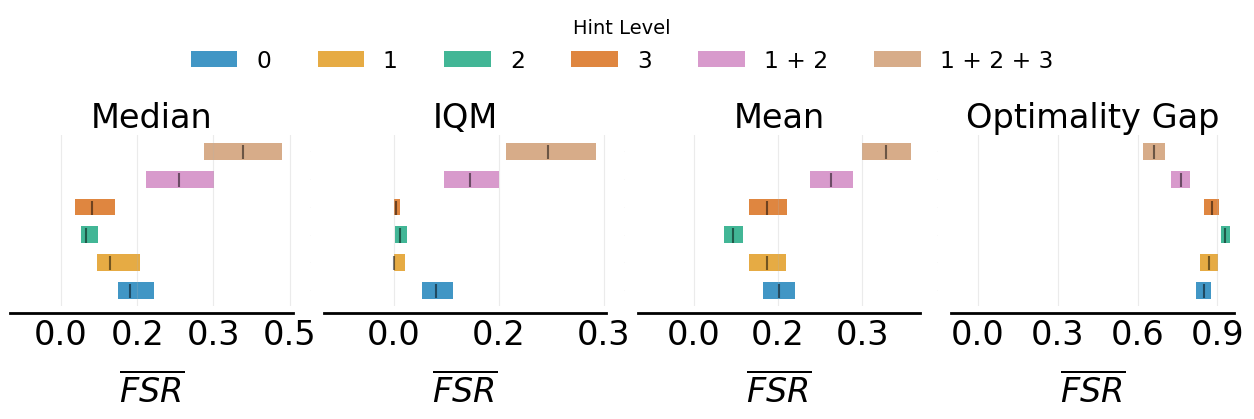

In [ ]:
from matplotlib.ticker import FuncFormatter

# Define a formatter to reduce the number of decimal digits
formatter = FuncFormatter(lambda x, _: f'{x:.1f}')

# fig, axes = plot_utils.plot_interval_estimates(
fig, axes = plot_interval_estimates(
    aggregate_scores_all_searches, aggregate_score_cis_all_searches,
    metric_names=['Median', 'IQM', 'Mean', 'Optimality Gap'],
    algorithms=searches, legend_name=[item.replace('Level ', '') for item in searches], xlabel='', legend_title='Hint Level',)

# Apply the formatter to all x-axes
for ax in axes:
    ax.xaxis.set_major_formatter(formatter)
    ax.set_xlim(left=-0.1)  # Set the x-axis to start from -0.

    # Adjust the position and font size of the xlabel for the IQM plot to avoid overlap
    ax.set_xlabel('$\overline{FSR}$', labelpad=15, fontsize=24)  # Increase labelpad and fontsize
# plt.show()
plt.savefig('figures/r1_hint.pdf', dpi=200, bbox_inches='tight')

In [35]:
results_by_config_all_hints = {}
for search_method in ['flat', 'tree', 'forest', 'ori_aide', 'multi_aide']:
    key_suffix = f"{search_method}_deepseek-r1"
    combined_exp_values = []

    for hint_regime in ['z', '1', '2', '5', '12', '125']:
        key = f"{search_method}_{hint_regime}_deepseek-r1"
        if key in results_by_config:
            combined_exp_values.append(results_by_config[key]['all_exp_values'])

    # Combine all experiments across hint regimes
    combined_exp_values = np.vstack(combined_exp_values)
    results_by_config_all_hints[f"{search_method}_deepseek-r1_all_hints"] = {
        'all_exp_values': combined_exp_values
    }

In [36]:
searches = ['flat_deepseek-r1_all_hints', 'tree_deepseek-r1_all_hints', 'forest_deepseek-r1_all_hints', 'ori_aide_deepseek-r1_all_hints', 'multi_aide_deepseek-r1_all_hints']
# Load ALE scores as a dictionary mapping algorithms to their human normalize
# score matrices, each of which is of size `(num_runs x num_games)`.
# atari_200m_normalized_score_dict = ...
searches_fsr_all_exp_values_dict = {key: value['all_exp_values'] for key, value in results_by_config_all_hints.items()}
aggregate_func = lambda x: np.array([
  metrics.aggregate_median(x),
  metrics.aggregate_iqm(x),
  metrics.aggregate_mean(x),
  metrics.aggregate_optimality_gap(x)])

In [37]:
searches_fsr_all_exp_values_dict.keys()

dict_keys(['flat_deepseek-r1_all_hints', 'tree_deepseek-r1_all_hints', 'forest_deepseek-r1_all_hints', 'ori_aide_deepseek-r1_all_hints', 'multi_aide_deepseek-r1_all_hints'])

In [38]:
aggregate_scores_all_hints, aggregate_score_cis_all_hints = rly.get_interval_estimates(
  searches_fsr_all_exp_values_dict, aggregate_func, reps=50000)


INFO:absl:Calculating estimates for flat_deepseek-r1_all_hints ...
INFO:absl:Calculating estimates for tree_deepseek-r1_all_hints ...
INFO:absl:Calculating estimates for forest_deepseek-r1_all_hints ...
INFO:absl:Calculating estimates for ori_aide_deepseek-r1_all_hints ...
INFO:absl:Calculating estimates for multi_aide_deepseek-r1_all_hints ...


In [39]:
aggregate_scores_all_hints, aggregate_score_cis_all_hints

({'flat_deepseek-r1_all_hints': array([0.14609362, 0.03679995, 0.17780538, 0.83210784]),
  'tree_deepseek-r1_all_hints': array([0.15093975, 0.04183858, 0.16346543, 0.83786214]),
  'forest_deepseek-r1_all_hints': array([0.14363736, 0.02992025, 0.16435069, 0.83824294]),
  'ori_aide_deepseek-r1_all_hints': array([0.14497704, 0.03164549, 0.17520351, 0.82608091]),
  'multi_aide_deepseek-r1_all_hints': array([0.1951889 , 0.07519752, 0.21204888, 0.78929816])},
 {'flat_deepseek-r1_all_hints': array([[0.09836127, 0.01931413, 0.14390894, 0.8011918 ],
         [0.20022074, 0.0593432 , 0.21428884, 0.86166066]]),
  'tree_deepseek-r1_all_hints': array([[0.10593201, 0.02281863, 0.13477456, 0.80817904],
         [0.20256937, 0.06472681, 0.19363264, 0.86620478]]),
  'forest_deepseek-r1_all_hints': array([[0.09747192, 0.01476536, 0.13342749, 0.80682207],
         [0.19716055, 0.05213949, 0.19677493, 0.86831993]]),
  'ori_aide_deepseek-r1_all_hints': array([[0.09825814, 0.01349376, 0.14376402, 0.79397488

In [40]:
hints = ['flat_deepseek-r1_all_hints', 'tree_deepseek-r1_all_hints', 'forest_deepseek-r1_all_hints', 'ori_aide_deepseek-r1_all_hints', 'multi_aide_deepseek-r1_all_hints']
hints = ['Flat', 'Tree', 'Forest', 'AIDE', 'MultiAIDE']
hints_replace = {
    'flat_deepseek-r1_all_hints': 'Flat',
    'tree_deepseek-r1_all_hints': 'Tree',
    'forest_deepseek-r1_all_hints': 'Forest',
    'ori_aide_deepseek-r1_all_hints': 'AIDE',
    'multi_aide_deepseek-r1_all_hints': 'MultiAIDE',
}
aggregate_scores_all_hints = {hints_replace[k]: v for k, v in aggregate_scores_all_hints.items()}
aggregate_score_cis_all_hints = {hints_replace[k]: v for k, v in aggregate_score_cis_all_hints.items()}

<>:18: SyntaxWarning: invalid escape sequence '\o'
<>:18: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_3497394/1205807250.py:18: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel('$\overline{FSR}$', labelpad=15, fontsize=24)  # Increase labelpad and fontsize


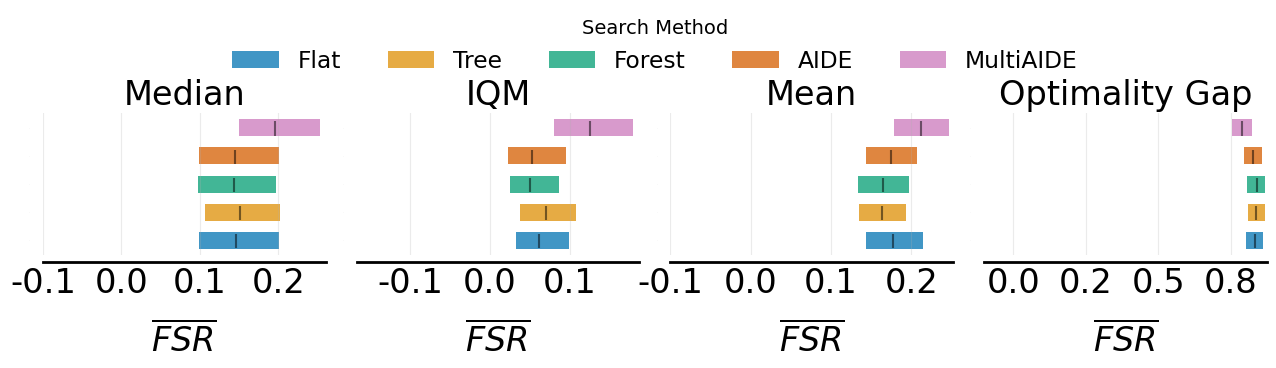

In [ ]:
from matplotlib.ticker import FuncFormatter

# Define a formatter to reduce the number of decimal digits
formatter = FuncFormatter(lambda x, _: f'{x:.1f}')

# fig, axes = plot_utils.plot_interval_estimates(
fig, axes = plot_interval_estimates(
    aggregate_scores_all_hints, aggregate_score_cis_all_hints,
    metric_names=['Median', 'IQM', 'Mean', 'Optimality Gap'],
    algorithms=hints, legend_name=hints, legend_title='Search Method', xlabel='',)

# Apply the formatter to all x-axes
for ax in axes:
    ax.xaxis.set_major_formatter(formatter)
    ax.set_xlim(left=-0.1)  # Set the x-axis to start from -0.

    # Adjust the position and font size of the xlabel for the IQM plot to avoid overlap
    ax.set_xlabel('$\overline{FSR}$', labelpad=15, fontsize=24)  # Increase labelpad and fontsize
# plt.show()
plt.savefig('figures/r1_search.pdf', dpi=200, bbox_inches='tight')